**To do**
1. ICBHI 데이터 공식 split 필요
    - ~~파일이름 변경~~ → 완료
    - train/test 구분 (공식, 6:4)  
    (Train: 539, Test: 381, Total 920)
    - pretext(80), finetuning(20) 으로 나누기


2. 전처리 고민 (데이터 특성을 고려한 전처리)
    - Sr (4KHz, 16KHz)
    - Augmentation (일단 SpecAug 부터)
    - 호흡 주기 seg
    - 하이퍼 파라미터

3. 일단 Finetuning 성공 문제


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import os
import numpy as np
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import math
from tqdm import tqdm
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


In [4]:
import pandas as pd

csv_path = "../data/ICBHI_challenge_train_test.csv"
df = pd.read_csv(csv_path, delimiter='\t', header=None)

# 컬럼 이름 수정 (좀 더 깔끔하게)
df.columns = ['filename', 'set']

# train, test 데이터 나누기
train_df = df[df['set'] == 'train']
test_df = df[df['set'] == 'test']

## 1. Data Load

In [5]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random

# WAV 파일이 있는 디렉토리 경로
data_dir = "../data/ICBHI_resample_4000"
txt_dir = "../data/ICBHI_final_database"

train_list = sorted(train_df['filename'].tolist())
test_list = sorted(test_df['filename'].tolist())

In [6]:
print(f'Train :{len(train_list)}, Test: {len(test_list)}, Total: {len(train_list) + len(test_list)}')

Train :539, Test: 381, Total: 920


#### Dataset util (func)

- get class
- Mel Spectogram 생성 (sr, frame_size, hop_length, n_mels)
- cycle 나누기 (start-end, append list)
- cycle repeat
- spec aug

In [7]:
# cycle 로부터 label 설정
def get_class(cr, wh):
    if cr == 1 and wh == 1:
        return 3
    elif cr == 0 and wh == 1:
        return 2
    elif cr == 1 and wh == 0:
        return 1
    elif cr == 0 and wh == 0:
        return 0
    else:
        return -1

In [8]:
#  Mel Spectrogram 생성
def generate_mel_spectrogram(waveform, sample_rate, frame_size=1024, hop_length=None, n_mels=128):
    if hop_length is None:
        hop_length = frame_size // 2
    mel_spec_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=frame_size,
        hop_length=hop_length,
        n_mels=n_mels
    )
    mel_spectrogram = mel_spec_transform(waveform)
    mel_db = T.AmplitudeToDB()(mel_spectrogram)
    return mel_db

In [9]:
 # 사이클 정보 사용하여 데이터 나누기
def crop_cycle_mel_segment(mel_db, start_time, end_time, sample_rate, hop_length):

    start_sample = int(start_time * sample_rate)
    end_sample = int(end_time * sample_rate)

    if end_sample <= start_sample:
        return None

    start_frame = start_sample // hop_length
    end_frame = end_sample // hop_length
    mel_segment = mel_db[:, :, start_frame:end_frame]  # shape: [1, n_mels, frames]

    return mel_segment

def process_cycles(cycle_data, lung_labels, mel_db, sample_rate, hop_length, target_duration=8):
    target_frames = target_duration * sample_rate // hop_length
    mel_cycles = []

    for (start_time, end_time), (cr, wh) in zip(cycle_data, lung_labels):
        cr, wh = int(cr), int(wh)
        start_sample = int(start_time * sample_rate)
        end_sample = int(end_time * sample_rate)

        mel_segment_cycle = crop_cycle_mel_segment(
            mel_db, start_time, end_time, sample_rate, hop_length
        )
        if mel_segment_cycle is None:
            continue

        mel_cycles.append((mel_segment_cycle,get_class(cr, wh),target_frames)) # mel_cycles = cycle, label, target_frame

    return mel_cycles

In [10]:
 # 사이클 데이터 Repeat
def repeat_or_truncate_segment(mel_segment, target_frames):
    current_frames = mel_segment.shape[-1]
    if current_frames >= target_frames:
        return mel_segment[:, :, :target_frames]
    else:
        repeat_ratio = math.ceil(target_frames / current_frames)
        mel_segment = mel_segment.repeat(1, 1, repeat_ratio)
        return mel_segment[:, :, :target_frames]

In [11]:
# 데이터 Spec Augmentation
def apply_spec_augment(mel_segment):
    M = mel_segment.shape[-1]
    F = mel_segment.shape[-2]

    time_masking = T.TimeMasking(time_mask_param=max(1, M // 2))
    freq_masking = T.FrequencyMasking(freq_mask_param=max(1, F // 2))

    aug1 = freq_masking(mel_segment.clone())
    aug2 = time_masking(mel_segment.clone())
    aug3 = freq_masking(time_masking(mel_segment.clone()))

    return aug1, aug2, aug3

#### DataSet

In [12]:
import os
import torch
import torchaudio
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm

class CycleDataset(Dataset):
    def __init__(self, filename_list, wav_dir, txt_dir, target_sec=5, sr=4000, frame_size=1024, hop_length=512, n_mels=128):
        self.filename_list = filename_list
        self.wav_dir = wav_dir
        self.txt_dir = txt_dir
        self.target_sec = target_sec
        self.sample_rate = sr
        self.frame_size = frame_size
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.target_frames = target_sec * sr // (self.hop_length)  # target frames for mel spectrogram


        self.cycle_list = []

        print("[INFO] Preprocessing cycles...")
        for filename in tqdm(self.filename_list):
            txt_path = os.path.join(self.txt_dir, filename + '.txt')
            wav_path = os.path.join(self.wav_dir, 'R' + filename + '.wav')

            if not os.path.exists(txt_path):
                print(f"[WARNING] Missing file: {txt_path}")
            if not os.path.exists(wav_path):
                print(f"[WARNING] Missing file: {wav_path}")

            # Load annotation
            cycle_data = np.loadtxt(txt_path, usecols=(0, 1))
            lung_label = np.loadtxt(txt_path, usecols=(2, 3))

            # Load waveform
            waveform, sample_rate = torchaudio.load(wav_path)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)  # Stereo to mono

            for idx in range(len(cycle_data)):
                start_sample = int(cycle_data[idx, 0] * sample_rate)
                end_sample = int(cycle_data[idx, 1] * sample_rate)
                lung_duration = cycle_data[idx, 1] - cycle_data[idx, 0]

                if end_sample <= start_sample:
                    continue  # 잘못된 구간 스킵

                cycle_wave = waveform[:, start_sample:end_sample]
                mel = generate_mel_spectrogram(cycle_wave, sample_rate, frame_size=self.frame_size, hop_length=self.hop_length, n_mels=self.n_mels)
                repeat_mel = repeat_or_truncate_segment(mel, target_frames=self.target_frames) # input shape: [1, 224, 224] 맞추기 위함

                # crackle, wheeze -> class
                cr = int(lung_label[idx, 0])
                wh = int(lung_label[idx, 1])
                label = get_class(cr, wh)

                # meta_data
                meta_data = (filename, lung_duration)

                self.cycle_list.append((repeat_mel, label, meta_data))

        print(f"[INFO] Total cycles collected: {len(self.cycle_list)}")

    def __len__(self):
        return len(self.cycle_list)

    def __getitem__(self, idx):
        repeat_mel, label, meta_data = self.cycle_list[idx]
        return repeat_mel, label, meta_data


In [14]:
import random
import matplotlib.pyplot as plt
import librosa.display

wav_dir = "../data/ICBHI_resample_4000"
txt_dir = "../data/ICBHI_final_database"

# 1. Dataset 로드
train_dataset = CycleDataset(train_list, wav_dir, txt_dir)
test_dataset = CycleDataset(test_list, wav_dir, txt_dir)

# # 1. Dataset 로드
# train_dataset = CycleDataset(
#     filename_list=train_list,
#     wav_dir=wav_dir,
#     txt_dir=txt_dir,
#     target_sec=8,
#     sr=4000,
#     frame_size=1024,
#     hop_length=512,
#     n_mels=128
# )

# 2. 간단 통계
print(f"Total cycles: {len(train_dataset)}")

label_counter = [0] * 4  # normal, crackle, wheeze, both
for _, label,_ in train_dataset:
    label_counter[label] += 1

for idx, count in enumerate(label_counter):
    print(f"Class {idx}: {count} cycles")


[INFO] Preprocessing cycles...


100%|██████████| 539/539 [00:07<00:00, 75.18it/s]


[INFO] Total cycles collected: 4142
[INFO] Preprocessing cycles...


100%|██████████| 381/381 [00:07<00:00, 50.52it/s]

[INFO] Total cycles collected: 2756
Total cycles: 4142
Class 0: 2063 cycles
Class 1: 1215 cycles
Class 2: 501 cycles
Class 3: 363 cycles


#### Data Imbalnce - Patient & Cycle


/var/tmp/ipykernel_7388/1770118555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'patient_id'] = train_df['filename'].apply(lambda x: x.split('_')[0])


,patient_id,patient_count
0,130,66
1,107,28
2,138,27
3,172,27
4,158,24
5,186,24
6,162,24
7,154,23
8,200,23
9,203,21


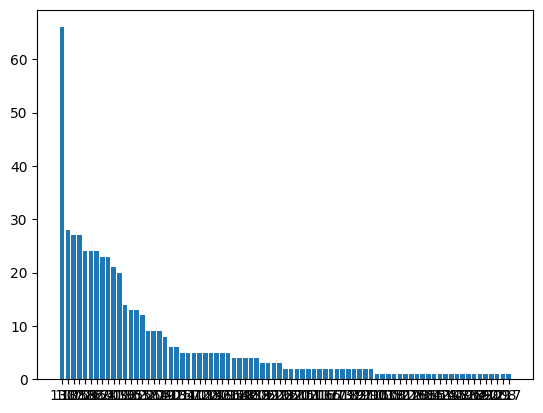

In [15]:
# train_df에 patient_id 컬럼 직접 추가
train_df.loc[:, 'patient_id'] = train_df['filename'].apply(lambda x: x.split('_')[0])

# 그 후에 value_counts 사용
patient_counts = train_df['patient_id'].value_counts().sort_values(ascending=False)

# DataFrame으로 변환
patient_counts_df = pd.DataFrame({
    'patient_id': patient_counts.index,
    'patient_count': patient_counts.values
})

# 상위 5개 확인
plt.bar(patient_counts_df['patient_id'], patient_counts_df['patient_count'])
patient_counts_df.head(10)

,patient_id,Cycle_count
0,130,507
1,107,231
2,158,217
3,154,208
4,203,185
5,172,176
6,138,149
7,193,138
8,213,129
9,186,126


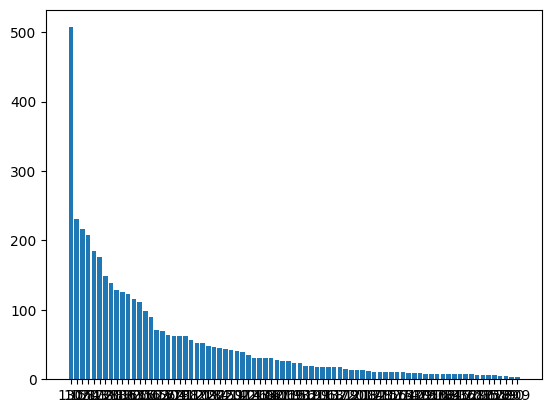

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# patient_id 추출 및 DataFrame 만들기
train_cycle = pd.DataFrame([(meta[0], meta[0].split('_')[0]) for _, _, meta in train_dataset], columns=['filename', 'patient_id'])

# patient_id별 발생 빈도수 계산
patient_counts_df = train_cycle['patient_id'].value_counts().reset_index()
patient_counts_df.columns = ['patient_id', 'Cycle_count']

# bar plot으로 시각화
plt.bar(patient_counts_df['patient_id'], patient_counts_df['Cycle_count'])
patient_counts_df.head(10)

#### Lung Sound Duration

mean duration: 2.7371561202317722 sec
Duration count per second:
0 sec: 194 cycles
1 sec: 805 cycles
2 sec: 1834 cycles
3 sec: 782 cycles
4 sec: 345 cycles
5 sec: 85 cycles
6 sec: 62 cycles
7 sec: 25 cycles
8 sec: 6 cycles
9 sec: 2 cycles
11 sec: 1 cycles
16 sec: 1 cycles


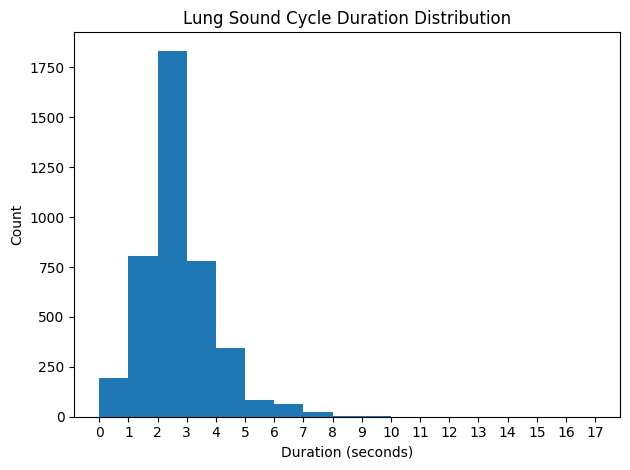

In [17]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# CycleDataset 인스턴스를 dataset이라고 가정
durations = [meta[1] for _, _, meta in train_dataset]

print(f"mean duration: {np.mean(durations)} sec")

# 히스토그램 그리기 (bin을 1초 단위로 설정)
plt.hist(durations, bins=np.arange(0, max(durations)+1, 1))

# 결과 출력
duration_counts = Counter(np.floor(durations).astype(int))  # 초 단위로 반올림 (소수점 버리기)
print("Duration count per second:")
for second in sorted(duration_counts.keys()):
    print(f"{second} sec: {duration_counts[second]} cycles")

# 그래프 설정
plt.title('Lung Sound Cycle Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count')
plt.xticks(np.arange(0, max(durations)+1, 1))  # x축에 모든 초 표시
plt.tight_layout()
plt.show()


#### Mel Visualization

<Figure size 1200x600 with 0 Axes>

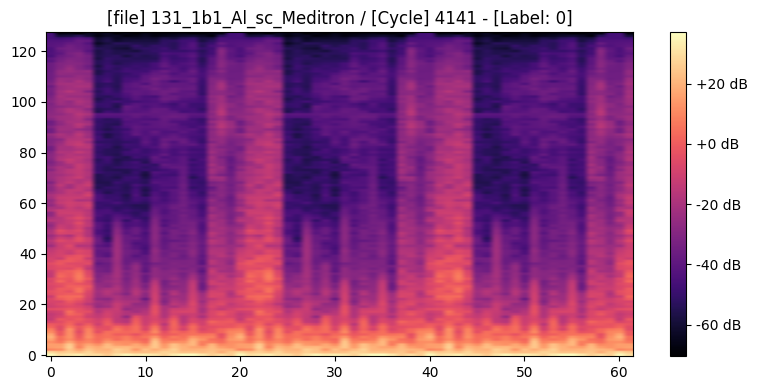

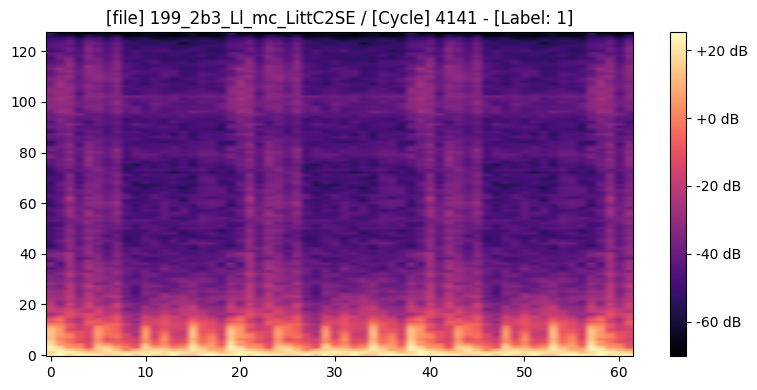

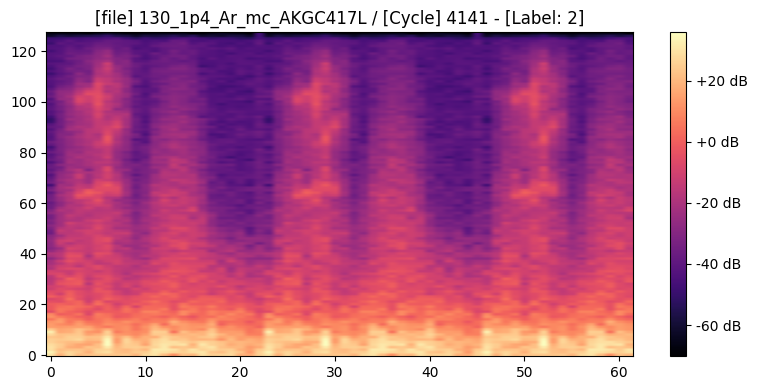

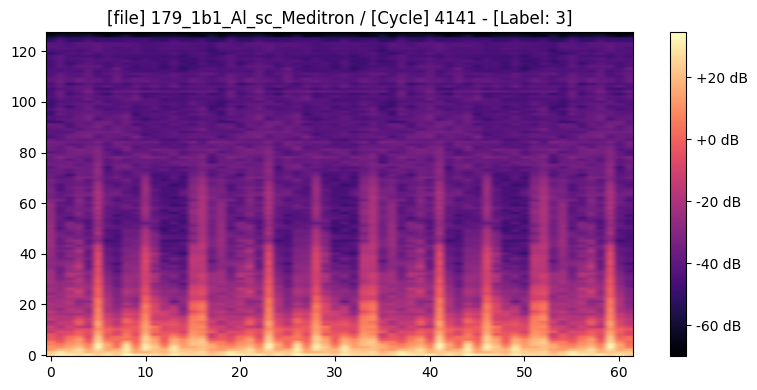

In [18]:
import random
import matplotlib.pyplot as plt

# label별로 인덱스를 그룹화
label_to_indices = {label: [] for label in set([train_dataset[idx][1] for idx in range(len(train_dataset))])}

for idx in range(len(train_dataset)):
    _, label, _ = train_dataset[idx]
    label_to_indices[label].append(idx)

# 각 label에서 2개씩 랜덤하게 샘플을 뽑아서 시각화
n_labels = len(label_to_indices)
samples_per_label = 1  # 각 label에서 2개씩 샘플 선택

plt.figure(figsize=(12, 6))

for i, (label, indices) in enumerate(label_to_indices.items()):
    # 각 label에서 2개씩 샘플을 랜덤하게 뽑기
    sample_indices = random.sample(indices, samples_per_label)

    for j, sample_idx in enumerate(sample_indices):
        mel, label, meta = train_dataset[sample_idx]

        # 시각화 (2개씩 가로로 나열)
        plt.figure(figsize=(8, 4))
        plt.imshow(mel.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
        plt.title(f"[file] {meta[0]} / [Cycle] {idx} - [Label: {label}]")
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()

plt.show()

#### 3.1 HyperParameter

In [48]:
class Args:
    gpu = 0
    batch_size = 64
    workers = 4
    epochs = 300
    lr = 0.01
    momentum = 0.9
    weight_decay = 1e-4
    data = "./data_path"
    print_freq = 100
    out_dim = 128
    mlp = True
    resume = None
    schedule=[120, 160] # schedule
    # target_frames =
            
    warm = True                      # warm-up 사용 여부
    warm_epochs = 10                # warm-up 적용할 초기 epoch 수
    warmup_from = lr * 0.1             # warm-up 시작 learning rate (보통 lr의 10%)
    warmup_to = lr     


args = Args()

### DataLoader - WeightedRandomSampler

- Pretext, Fine = 8:2 비율  
- StratifiedShuffle - 클래스 비율 유지
- WeightedRandomSampler 통한 DataLoader 구성

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset

# labels
labels = torch.tensor([label for _, label, _ in train_dataset])

# Stratified Split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for pretext_idx, finetune_idx in sss.split(torch.zeros(len(labels)), labels):
    print(f"Pretext set size: {len(pretext_idx)}, Finetune set size: {len(finetune_idx)}")

# Subset - DataLoader Input
pretext_dataset = Subset(train_dataset, pretext_idx)
finetune_dataset = Subset(train_dataset, finetune_idx)


Pretext set size: 3313, Finetune set size: 829


In [21]:
# Pretext DataLoader
pre_labels = torch.tensor([train_dataset[idx][1] for idx in pretext_idx])
pre_class_counts = torch.bincount(pre_labels)
pre_class_weights = 1.0 / pre_class_counts.float()
pre_sample_weights = pre_class_weights[pre_labels]

pre_sampler = WeightedRandomSampler(
    weights=pre_sample_weights,
    num_samples=len(pre_sample_weights),
    replacement=True
)

pretext_loader = DataLoader(
    pretext_dataset,
    batch_size=args.batch_size,
    sampler=pre_sampler,
    num_workers=4,
    drop_last=True,
    pin_memory=True
)

# finetune DataLoader
fin_labels = torch.tensor([train_dataset[idx][1] for idx in finetune_idx])
fin_class_counts = torch.bincount(fin_labels)
fin_class_weights = 1.0 / fin_class_counts.float()
fin_sample_weights = fin_class_weights[fin_labels]

fin_sampler = WeightedRandomSampler(
    weights=fin_sample_weights,
    num_samples=len(fin_sample_weights),
    replacement=True
)

finetune_loader = DataLoader(
    finetune_dataset,
    batch_size=args.batch_size,
    sampler=fin_sampler,
    num_workers=4,
    drop_last=True,
    pin_memory=True
)

# Test DataLoader


/opt/conda/envs/boaz/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [22]:
from collections import Counter

# pretext와 finetune 데이터셋의 라벨 분포 출력
pretext_labels = labels[pretext_idx]
finetune_labels = labels[finetune_idx]

print(f"[Pretext Dataset] Total: {len(pretext_labels)}")
print("Pretext label distribution:", Counter(pretext_labels.tolist()))
print(f"\n[Finetune Dataset] Total: {len(finetune_labels)}")
print("Finetune label distribution:", Counter(finetune_labels.tolist()))


[Pretext Dataset] Total: 3313
Pretext label distribution: Counter({0: 1650, 1: 972, 2: 401, 3: 290})

[Finetune Dataset] Total: 829
Finetune label distribution: Counter({0: 413, 1: 243, 2: 100, 3: 73})


## 2. Model

#### 2.1 Pre-trained ResNet50

In [23]:
import torch
import torchvision
from torch import Tensor
import torch.nn as nn
import math
import numpy as np
import torch.nn.functional as F
from torch.hub import load_state_dict_from_url
from torchvision.models import ResNet50_Weights


# # from https://github.com/raymin0223/patch-mix_contrastive_learning/blob/main/models/resnet.py

# class ResNet50(torchvision.models.resnet.ResNet):
#     def __init__(self, track_bn=True, num_classes):
#         def norm_layer(*args, **kwargs):
#             return nn.BatchNorm2d(*args, **kwargs, track_running_stats=track_bn)
#         super().__init__(torchvision.models.resnet.Bottleneck, [3, 4, 6, 3], norm_layer=norm_layer)
#         del self.fc
#         self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.final_feat_dim = 2048
#         self.num_classes = num_classes

#     def load_sl_official_weights(self, progress=True):
#         state_dict = load_state_dict_from_url(torchvision.models.resnet.model_urls['resnet50'],
#                                               progress=progress)

#         del state_dict['conv1.weight']
#         missing, unexpected = self.load_state_dict(state_dict, strict=False)
#         # if len(missing) > 0:
#             # raise AssertionError('Model code may be incorrect')

#     def _forward_impl(self, x: Tensor) -> Tensor:
#         # See note [TorchScript super()]
#         x = self.conv1(x)
#         x = self.bn1(x)
#         x = self.relu(x)
#         x = self.maxpool(x)

#         x = self.layer1(x)
#         x = self.layer2(x)
#         x = self.layer3(x)
#         x = self.layer4(x)

#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         # x = self.fc(x)

#         return x

import torch
import torch.nn as nn
import torchvision.models as models
from torch.hub import load_state_dict_from_url

def backbone_resnet(num_classes=128):
    # 1. 기본 resnet50 구조 생성 (pretrained X)
    resnet = models.resnet50(weights=None)

    # 2. 첫 번째 conv 레이어를 1채널용으로 수정
    resnet.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # 3. pretrained weight 불러오기 (conv1은 제외)
    url = ResNet50_Weights.IMAGENET1K_V2.url
    state_dict = load_state_dict_from_url(url, progress=True)
    if 'conv1.weight' in state_dict:
        del state_dict['conv1.weight']
    resnet.load_state_dict(state_dict, strict=False)

    # 4. fc 레이어를 원하는 클래스로 변경
    resnet.fc = nn.Linear(2048, num_classes)

    return resnet


In [24]:
# import torchvision.models as models
# from torchsummary import summary
# import torch.nn as nn

# def resnet(num_classes=128):
#     # 1. 기본 resnet50 불러오기
#     resnet = models.resnet50(weights="IMAGENET1K_V2")# Resnet ImageNet pretrained

#     # 2. 첫 번째 conv 레이어를 1채널용으로 수정 (기존: Conv2d(3, 64, ...))
#     resnet.conv1 = nn.Conv2d(
#         in_channels=1,       # 오디오나 흑백 이미지
#         out_channels=64,
#         kernel_size=7,
#         stride=2,
#         padding=3,
#         bias=False
#     )

#     ## 마지막 feature 는 (batch, channels, 1, 1) 이 나옴.

#     # 3. MoCo(MLP=True) -> 마지막 fc 레이어는 Moco Class 내부에서 MLP 로 바꿔줌
#     resnet.fc = nn.Linear(2048, num_classes)

#     return resnet

In [25]:
# summary 함수 사용: (채널, 높이, 너비) 크기를 지정
summary(backbone_resnet().to(device), input_size=(1, 224, 64))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/sbw/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 94.9MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 64, 112, 32]           3,136
       BatchNorm2d-2          [-1, 64, 112, 32]             128
              ReLU-3          [-1, 64, 112, 32]               0
         MaxPool2d-4           [-1, 64, 56, 16]               0
            Conv2d-5           [-1, 64, 56, 16]           4,096
       BatchNorm2d-6           [-1, 64, 56, 16]             128
              ReLU-7           [-1, 64, 56, 16]               0
            Conv2d-8           [-1, 64, 56, 16]          36,864
       BatchNorm2d-9           [-1, 64, 56, 16]             128
             ReLU-10           [-1, 64, 56, 16]               0
           Conv2d-11          [-1, 256, 56, 16]          16,384
      BatchNorm2d-12          [-1, 256, 56, 16]             512
           Conv2d-13          [-1, 256, 56, 16]          16,384
      BatchNorm2d-14          [-1, 256,

#### 2.2 Moco

In [26]:
import torch
import torch.nn as nn

class MoCo(nn.Module):
    """
    Build a MoCo model with: a query encoder, a key encoder, and a queue
    https://arxiv.org/abs/1911.05722
    """

    def __init__(self, base_encoder, dim=128, K=8192, m=0.999, T=0.07, mlp=False):
        """
        dim: feature dimension (default: 128)
        K: queue size; number of negative keys (default: 65536)
        m: moco momentum of updating key encoder (default: 0.999)
        T: softmax temperature (default: 0.07)
        """
        super(MoCo, self).__init__()

        self.K = K
        self.m = m
        self.T = T

        # create the encoders
        # num_classes is the output fc dimension
        self.encoder_q = base_encoder(num_classes=dim)
        self.encoder_k = base_encoder(num_classes=dim)

        if mlp:  # hack: brute-force replacement
            dim_mlp = self.encoder_q.fc.weight.shape[1]
            self.encoder_q.fc = nn.Sequential(
                nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.encoder_q.fc
            )
            self.encoder_k.fc = nn.Sequential(
                nn.Linear(dim_mlp, dim_mlp), nn.ReLU(), self.encoder_k.fc
            )

        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data.copy_(param_q.data)  # initialize
            param_k.requires_grad = False  # not update by gradient

        # create the queue
        self.register_buffer("queue", torch.randn(dim, K))
        self.queue = nn.functional.normalize(self.queue, dim=0)

        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """
        Momentum update of the key encoder
        """
        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data = param_k.data * self.m + param_q.data * (1.0 - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        # gather keys before updating queue
        keys = keys

        batch_size = keys.shape[0]

        ptr = int(self.queue_ptr)
        assert self.K % batch_size == 0  # for simplicity

        # replace the keys at ptr (dequeue and enqueue)
        self.queue[:, ptr : ptr + batch_size] = keys.T
        ptr = (ptr + batch_size) % self.K  # move pointer

        self.queue_ptr[0] = ptr

    def forward(self, im_q, im_k):
        """
        Input:
            im_q: a batch of query images
            im_k: a batch of key images
        Output:
            logits, targets
        """

        # compute query features
        q = self.encoder_q(im_q)  # queries: NxC
        q = nn.functional.normalize(q, dim=1)

        # compute key features
        with torch.no_grad():  # no gradient to keys
            self._momentum_update_key_encoder()  # update the key encoder
            k = self.encoder_k(im_k)  # keys: NxC
            k = nn.functional.normalize(k, dim=1)

        # compute logits
        # Einstein sum is more intuitive
        # positive logits: Nx1
        l_pos = torch.einsum("nc,nc->n", [q, k]).unsqueeze(-1) # [N, 1]
        # negative logits: NxK
        l_neg = torch.einsum("nc,ck->nk", [q, self.queue.clone().detach()])  # [N,dim] * [dim,K] = [N,K]


        # logits: Nx(1+K)
        logits = torch.cat([l_pos, l_neg], dim=1) # [N, 1+K]

        # apply temperature
        logits /= self.T

        # labels: positive key indicators
        labels = torch.zeros(logits.shape[0], dtype=torch.long).cuda()

        # dequeue and enqueue
        self._dequeue_and_enqueue(k)

        return logits, labels

## 3. Training

In [27]:
next(iter(pretext_loader))[0][0].shape

/opt/conda/envs/boaz/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


torch.Size([1, 128, 62])

#### 3.2 TestData Loader

In [28]:
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=4)


#### 3.3 Aug

In [29]:
def aug(repeat_mel):
    aug1, aug2, aug3 = apply_spec_augment(repeat_mel)
    return aug1, aug2, aug3

#### Wandb

In [30]:
import wandb

wandb.login(key='37e029d940c3722b338d8079392931beecdbef3b')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/sbw/.netrc
wandb: Currently logged in as: boaz_woony (boaz_woony-boaz) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [54]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,▃▇██▇▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▃▂▂▂▁▁▂▂▁
epoch,31
train_loss,6.83684


In [49]:
project_name = 'WarmO_batch64_lr0.01_sbw_3.0_Moco_ICBHI_Standard_256batch_'

In [50]:

import wandb

# wandb 초기화 (프로젝트명, 실험 이름 등 설정)
wandb.init(
    project="SBW_ICBHI_SSL",           # 프로젝트 이름
    name=f"{project_name}", # 실험 이름
    config={
        "epochs": args.epochs,
        "batch_size": args.batch_size,
        "lr": args.lr,
        "momentum": args.momentum,
        "weight_decay": args.weight_decay
    }
)


## Visualization


Original dB Spectrogram shape: torch.Size([1, 128, 62])


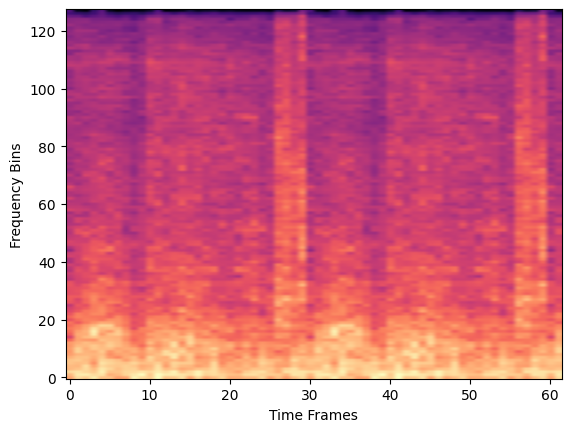

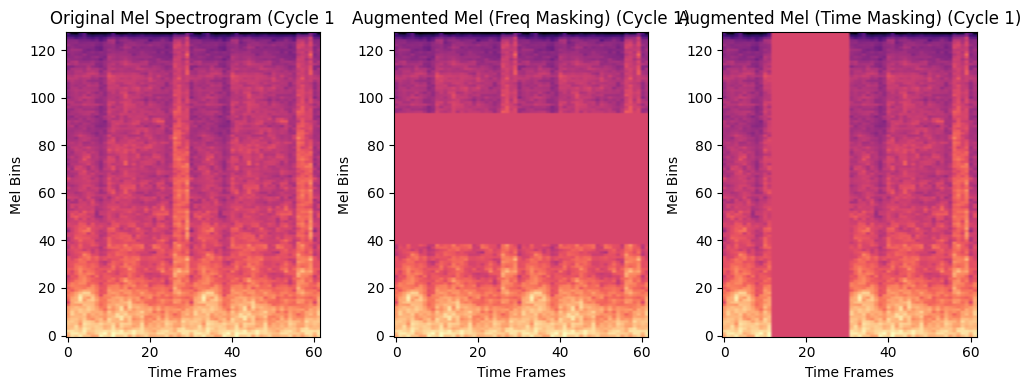

Original dB Spectrogram shape: torch.Size([1, 128, 62])


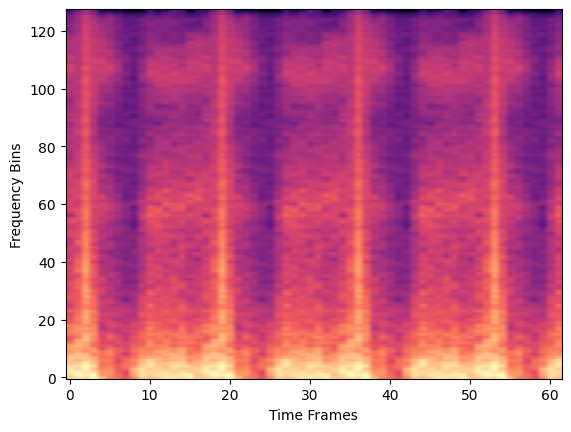

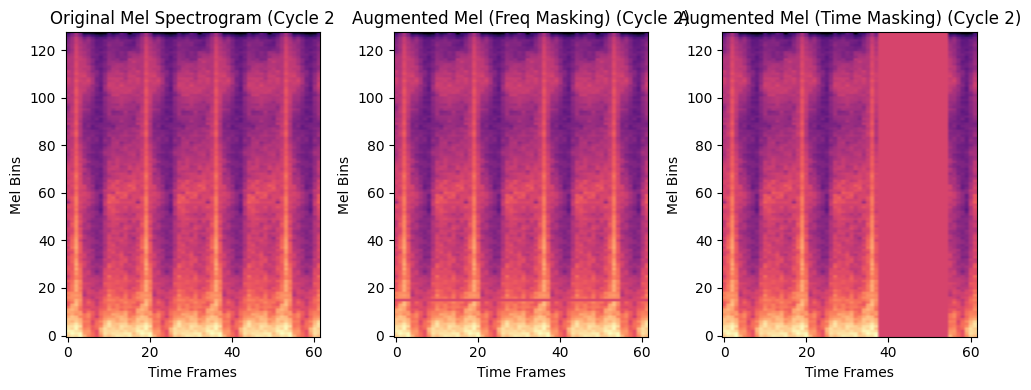

Original dB Spectrogram shape: torch.Size([1, 128, 62])


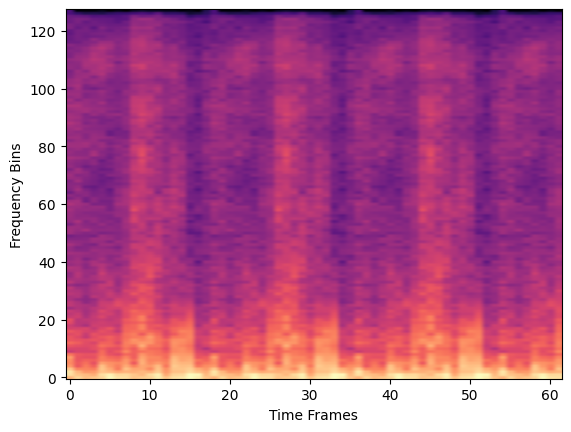

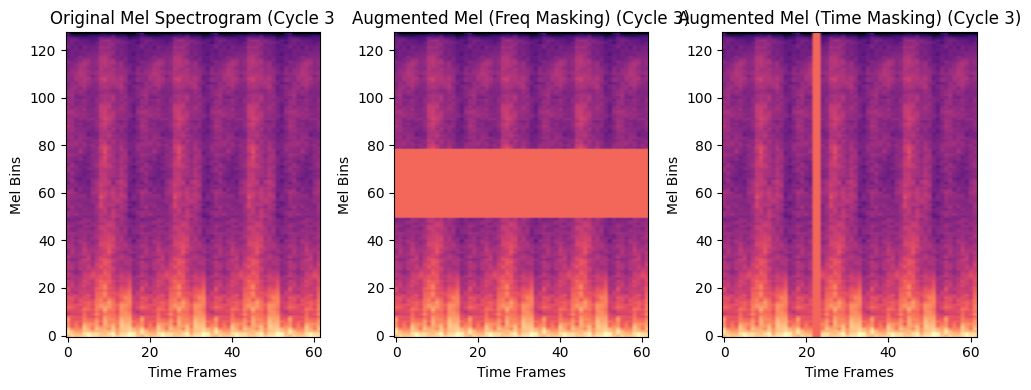

In [51]:
import matplotlib.pyplot as plt
import torchaudio.transforms as T
from itertools import islice

n_list = 3

# 🔹 각 파일별로 cycle segments 시각화
for i, cycle_data in enumerate(islice(pretext_dataset, n_list)):
    target_frame = 62
    cycle, label, _ = cycle_data

    # 1. segment repeat = 🔹 전체 원본 db 스펙트로그램 (크게 출력)
    origin_db = cycle  # 첫 번째 세그먼트에서 전체 db 스펙트로그램 사용
    print(f"Original dB Spectrogram shape: {origin_db.shape}")  # 🔹 데이터 shape 확인


    # 🔹 원본 dB Spectrogram을 크게 시각화
    fig, main_ax = plt.subplots()
    main_ax.imshow(origin_db.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    # main_ax.set_title(f"Original dB Spectrogram - {filename}")
    main_ax.set_xlabel("Time Frames")
    main_ax.set_ylabel("Frequency Bins")
    plt.show()

    # 2.세그먼트 개수에 맞게 서브플롯 생성 (repeat + 두 가지 Augment 버전)
    fig, axes = plt.subplots(1, 3, figsize=(10, 4)) # plt.subplots(행, 열, figsize)

    ax1, ax2, ax3 = axes

    repeat = repeat_or_truncate_segment(cycle, target_frame)
    augmented_spec1, augmented_spec2, augmented_spec3 = apply_spec_augment(repeat)

    # 🔹 원본 repeaet Mel Spectrogram 시각화
    ax1.imshow(repeat.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax1.set_title(f"Original Mel Spectrogram (Cycle {i+1}")
    ax1.set_xlabel("Time Frames")
    ax1.set_ylabel("Mel Bins")

    # 🔹 주파수 마스킹이 적용된 Mel Spectrogram 시각화
    ax2.imshow(augmented_spec1.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax2.set_title(f"Augmented Mel (Freq Masking) (Cycle {i+1})")
    ax2.set_xlabel("Time Frames")
    ax2.set_ylabel("Mel Bins")

    # 🔹 시간 마스킹이 적용된 Mel Spectrogram 시각화
    ax3.imshow(augmented_spec2.squeeze(0).numpy(), aspect='auto', origin='lower', cmap='magma')
    ax3.set_title(f"Augmented Mel (Time Masking) (Cycle {i+1})")
    ax3.set_xlabel("Time Frames")
    ax3.set_ylabel("Mel Bins")

    plt.tight_layout()
    plt.show()


#### 3.4 Train

In [52]:
args.warm_epochs

10

In [53]:
import math
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. MoCo 모델 생성
# default - base_encoder, dim=128, K=8192, m=0.999, T=0.07
model = MoCo(base_encoder = backbone_resnet, mlp=False).cuda()

# 2. loss function (criterion)
criterion = nn.CrossEntropyLoss() # .cuda(device.gpu)

# 3.Optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    args.lr,
    momentum=args.momentum,
    weight_decay=args.weight_decay,
)

# # 4. Cosine Schedular
# scheduler = CosineAnnealingLR(
#     optimizer,
#     T_max=args.epochs,
#     eta_min=0  # 최종적으로 0까지 떨어질 수 있도록
# )

# 4. Scheduler 정의
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=args.epochs - args.warm_epochs,  # Warm-up 이후 cosine decay
    eta_min=0  # 최종적으로 0까지 떨어질 수 있도록
)


# Best loss 초기화
best_loss = float('inf')
best_epoch = -1

for epoch in range(args.epochs):
        
    # Warm-up 또는 Cosine 적용
    if args.warm and epoch < args.warm_epochs:
        lr = args.warmup_from + (args.warmup_to - args.warmup_from) * epoch / args.warm_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        print(f"[Warm-up] Epoch {epoch}, LR: {lr:.6f}")
    else:
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        print(f"[Cosine] Epoch {epoch}, LR: {lr:.6f}")

    # # ===============================
    # # 1. Learning Rate Scheduler
    # # ===============================
    # lr = args.lr
    # if args.cos:
    #     lr *= 0.5 * (1. + math.cos(math.pi * epoch / args.epochs))
    # else:
    #     for milestone in args.schedule:
    #         if epoch >= milestone:
    #             lr *= 0.1
    # for param_group in optimizer.param_groups:
    #     param_group['lr'] = lr

    # print(f"\n==> [Epoch {epoch}] Adjusted learning rate: {lr:.6f}")

    # ===============================
    # 2. Training
    # ===============================
    model.train()
    total_train_loss = 0.0

    for i, (repeat_mel, label, _) in enumerate(pretext_loader): # label 여기선 사용 X
        im_q, im_k, _ = aug(repeat_mel)
        im_q = im_q.cuda(device=args.gpu, non_blocking=True)
        im_k = im_k.cuda(device=args.gpu, non_blocking=True)

        optimizer.zero_grad()
        output, target = model(im_q=im_q, im_k=im_k)
        loss = criterion(output, target) # NCE Loss ( = N*[1+k]의 유사도가 모두 0이 되도록 loss 조정)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        # if i % args.print_freq == 0:
        #     print(f"[Epoch {epoch} | Step {i}] Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(pretext_loader)
    print(f"Epoch {epoch} | Avg Train Loss: {avg_train_loss:.4f}")

    # =====================================
    # Schedular
    # =====================================
    # scheduler.step()

    # =====================================
    # 3. Logging with wandb
    # =====================================
    wandb.log({
        "epoch": epoch,
        "train_loss": avg_train_loss,
        # "lr": lr
    })

    # =====================================
    # 4. Checkpoint (Every 100 epochs)
    # =====================================
    if (epoch + 1) % 100 == 0:
        ckpt_path = './pth/' + f"{project_name}_{epoch:03d}.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }, ckpt_path)
        print(f"💾 Saved checkpoint to {ckpt_path}")

    # ===============================
    # 5. Save Best Checkpoint
    # ===============================
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        best_epoch = epoch
        best_ckpt_path = './best/'+ f"{project_name}_best_checkpoint.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': best_loss
        }, best_ckpt_path)
        print(f"=> Saved best checkpoint (epoch: {epoch}, loss: {best_loss:.4f})")

wandb.finish()

[Warm-up] Epoch 0, LR: 0.001000


/opt/conda/envs/boaz/lib/python3.10/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 0 | Avg Train Loss: 7.6155
=> Saved best checkpoint (epoch: 0, loss: 7.6155)
[Warm-up] Epoch 1, LR: 0.001900
Epoch 1 | Avg Train Loss: 8.7714
[Warm-up] Epoch 2, LR: 0.002800
Epoch 2 | Avg Train Loss: 9.1084
[Warm-up] Epoch 3, LR: 0.003700
Epoch 3 | Avg Train Loss: 8.9543
[Warm-up] Epoch 4, LR: 0.004600
Epoch 4 | Avg Train Loss: 8.7098
[Warm-up] Epoch 5, LR: 0.005500
Epoch 5 | Avg Train Loss: 8.5637
[Warm-up] Epoch 6, LR: 0.006400
Epoch 6 | Avg Train Loss: 8.3425
[Warm-up] Epoch 7, LR: 0.007300
Epoch 7 | Avg Train Loss: 8.2842
[Warm-up] Epoch 8, LR: 0.008200
Epoch 8 | Avg Train Loss: 8.1180
[Warm-up] Epoch 9, LR: 0.009100
Epoch 9 | Avg Train Loss: 8.1718
[Cosine] Epoch 10, LR: 0.009100
Epoch 10 | Avg Train Loss: 8.0302
[Cosine] Epoch 11, LR: 0.009099
Epoch 11 | Avg Train Loss: 8.1040
[Cosine] Epoch 12, LR: 0.009098
Epoch 12 | Avg Train Loss: 8.0084
[Cosine] Epoch 13, LR: 0.009096
Epoch 13 | Avg Train Loss: 7.9061
[Cosine] Epoch 14, LR: 0.009093
Epoch 14 | Avg Train Loss: 7.9141
[C

KeyboardInterrupt: 

In [38]:
cd ../

/home/sbw/boaz/code


In [52]:
wandb.finish()

Finetune/epoch,▁▂▃▄▅▆▇█
Finetune/test_accuracy,▁▁▃▄▆▇▇█
Finetune/test_loss,█▇▄▂▁▁▂▂
Finetune/train_accuracy,▁▂▂▅▇▇▇█
Finetune/train_loss,█▇▆▅▃▃▂▁
Metrics/f1_score,▁▁▄▅▆▇██
Metrics/precision,▁▁▄▅▇▇██
Metrics/recall,▁▁▃▅▆▇██
Metrics/specificity,▁▁▃▄▇▇██
Finetune/epoch,7
Finetune/test_accuracy,33.85341


## Fine tuning

In [24]:
len(test_dataset)

2756

In [57]:
class Args:
    gpu = 0
    batch_size = 128
    workers = 4
    epochs = 150
    lr = 0.02 # origin : 30
    momentum = 0.9
    weight_decay = 0
    out_dim = 128

args = Args()

In [58]:
finetune_project_name= 'sbw_3.0_Moco_Finetune_ICBHI_Standard_2_128batch_lr0.02'

In [59]:
import wandb

# wandb 초기화 (프로젝트명, 실험 이름 등 설정)
wandb.init(
    project="SBW_ICBHI_SSL",           # 프로젝트 이름
    name=f"{finetune_project_name}", # 실험 이름
    config={
        "epochs": 150,
        "batch_size": 128,
        "lr": 0.02,
        "momentum": 0.9,
        "weight_decay": 0
    }
)


In [ ]:
import os
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score


# 1. Model Load
# ckpt_path
load_ckpt_path = '/content/drive/MyDrive/BOAZ_ICBHI/pth/best/'
save_ckpt_path = '/content/drive/MyDrive/BOAZ_ICBHI/fine_tune_pth/'

# Load Encoder
model_eval = MoCo(base_encoder=backbone_resnet, dim=128, mlp=False)
checkpoint = torch.load(f"{load_ckpt_path}/sbw_3.0_Moco_ICBHI_Standard_2_best_checkpoint.pth.tar",
                      map_location=device)  # map_location 파라미터 추가
model_eval.load_state_dict(checkpoint["state_dict"])
encoder = model_eval.encoder_q.eval().to(device)

# 2. Dataset 정의
# Dataset 정의는 이미 되어있음 - test_loader

# 3. Fine-tuning을 위한 분류 모델 정의 ( Data 개수 작으므로, encoder 파라미터 frozen )
class FineTuningModel(nn.Module):
    def __init__(self, encoder, out_dim=args.out_dim, num_classes=4):
        super().__init__()
        self.encoder = encoder
        # 마지막 FC layer를 제외한 encoder의 모든 레이어 freeze
        for param in self.encoder.parameters():
            param.requires_grad = False

        # 새로운 분류 헤드 추가
        self.classifier = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)


# 4. 모델, 손실 함수, 옵티마이저 설정
model = FineTuningModel(encoder, out_dim = args.out_dim).to(device)
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
optimizer = optim.SGD(model.classifier.parameters(), lr = args.lr, momentum=0.9,weight_decay=0)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Best loss 초기화
best_loss = float('inf')
best_epoch = -1

# 5. Validation loop
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels, _ in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    accuracy = 100. * correct / total
    avg_loss = running_loss / len(val_loader)

    return avg_loss, accuracy, all_labels, all_preds


# 6. Fine-tuning 실행

for epoch in range(args.epochs):
    # # ===============================
    # # 1. Learning Rate Scheduler
    # # ===============================
    # lr = args.lr
    # if args.cos:
    #     lr *= 0.5 * (1. + math.cos(math.pi * epoch / args.epochs))
    # else:
    #     for milestone in args.schedule:
    #         if epoch >= milestone:
    #             lr *= 0.1
    # for param_group in optimizer.param_groups:
    #     param_group['lr'] = lr

    # print(f"\n==> [Epoch {epoch}] Adjusted learning rate: {lr:.6f}")

    # ===============================
    # 2. Training
    # ===============================
    model.train()
    total_loss = 0.0
    total_predictions = 0.0
    correct_predictions = 0.0

    pbar = tqdm(finetune_loader, desc='Training')
    for i, (cycle, labels, _) in enumerate(pbar):
        # Forward pass
        cycle = cycle.cuda(args.gpu)
        labels = labels.cuda(args.gpu)

        # backpropagation
        optimizer.zero_grad()
        output = model(cycle)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        # loss 계산
        total_loss += loss.item()

        _, predicted = torch.max(output.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': total_loss/total_predictions, 'train acc': 100.*correct_predictions/total_predictions})

    train_loss = total_loss / len(finetune_loader)
    train_acc = 100.*correct_predictions/total_predictions

    print(f"==> Epoch {epoch} completed.")
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')

    # ===============================
    # 3. Validation
    # ===============================

    test_loss, test_acc, all_labels, all_predictions = validate(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    # 성능 지표
    precision = precision_score(all_labels.numpy(), all_predictions.numpy(), average='macro')
    recall = recall_score(all_labels.numpy(), all_predictions.numpy(), average='macro')
    f1 = f1_score(all_labels.numpy(), all_predictions.numpy(), average='macro')

    # 특이도

    from sklearn.metrics import confusion_matrix

    def compute_specificity(y_true, y_pred, num_classes):
        cm = confusion_matrix(y_true, y_pred)
        specificities = []

        for i in range(num_classes):
            TP = cm[i, i]
            FN = cm[i, :].sum() - TP
            FP = cm[:, i].sum() - TP
            TN = cm.sum() - (TP + FN + FP)

            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
            specificities.append(specificity)

        return specificities

    specificity_per_class = compute_specificity(all_labels.numpy(), all_predictions.numpy(), num_classes=4)
    specificity = sum(specificity_per_class) / len(specificity_per_class)


    # =====================================
    # 4. Logging with wandb
    # =====================================

    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix

    def log_confusion_matrix_wandb(y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title('Confusion Matrix')
        plt.tight_layout()

        # wandb에 이미지로 로그
        wandb.log({"confusion_matrix": wandb.Image(fig)})
        plt.close(fig)



    wandb.log({
        "Finetune/epoch": epoch,
        "Finetune/train_loss": train_loss,
        "Finetune/train_accuracy": train_acc,
        "Finetune/test_loss": test_loss,
        "Finetune/test_accuracy": test_acc,
        "Metrics/precision": precision,
        "Metrics/recall": recall,
        "Metrics/f1_score": f1,
        "Metrics/specificity": specificity
    })

    # 혼동행렬은 따로 이미지로 로그
    log_confusion_matrix_wandb(
        y_true=all_labels.numpy(),
        y_pred=all_predictions.numpy(),
        class_names=["Normal", "Creekle", "Wheezle", "Both"]
    )

    # =====================================
    # 4. Checkpoint (Every 100 epochs)
    # =====================================
    if (epoch + 1) % 100 == 0:
        ckpt_path = save_ckpt_path + f"{finetune_project_name}_{epoch:03d}.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }, ckpt_path)
        print(f"💾 Saved checkpoint to {save_ckpt_path}")

    # ===============================
    # 5. Save Best Checkpoint
    # ===============================
    if train_loss < best_loss:
        best_loss = train_loss
        best_epoch = epoch
        best_ckpt_path = save_ckpt_path +"best/"+ f"{finetune_project_name}_best.pth.tar"
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'loss': best_loss
        }, best_ckpt_path)
        print(f"=> Saved best checkpoint (epoch: {epoch}, loss: {best_loss:.4f})")

wandb.finish()

Training:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training: 100%|██████████| 3/3 [00:00<00:00,  3.82it/s, loss=0.00554, train acc=29]

==> Epoch 0 completed.
Train Loss: 1.4186 | Train Acc: 29.04%


Test Loss: 1.4203 | Test Acc: 27.21%
=> Saved best checkpoint (epoch: 0, loss: 1.4186)


Training:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training: 100%|██████████| 3/3 [00:00<00:00,  4.13it/s, loss=0.00542, train acc=30.7]

==> Epoch 1 completed.
Train Loss: 1.3882 | Train Acc: 30.73%


...

Test Loss: 1.4009 | Test Acc: 37.63%
=> Saved best checkpoint (epoch: 32, loss: 0.9294)


Training:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training: 100%|██████████| 3/3 [00:00<00:00,  4.01it/s, loss=0.0036, train acc=63.9]

==> Epoch 33 completed.
Train Loss: 0.9225 | Train Acc: 63.93%


Test Loss: 1.3959 | Test Acc: 38.10%
=> Saved best checkpoint (epoch: 33, loss: 0.9225)


Training:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Training:  67%|██████▋   | 2/3 [00:00<00:00,  4.42it/s, loss=0.00394, train acc=59]